In [1]:
import os

emb_dir = os.path.join('..', 'embedding', 'word_embeddings_cleaned')

In [2]:
import numpy as np

def read_vec_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        # Read the first line to get dimensions
        header = f.readline().split()
        n_vectors = int(header[0])
        dim = int(header[1])
        
        print(f"Loading {n_vectors} vectors of dimension {dim}...")

        # usecols=range(1, dim + 1) ensures we skip the label 
        # and grab all 'dim' numerical values.
        vectors = np.loadtxt(f, delimiter=' ', usecols=range(1, dim + 1))
        
    print(f"Final shape: {vectors.shape}")
    return vectors

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# import matplotlib.pyplot as plt

# # Add this inside your print_similarity_stats function, after computing unique_similarities
# # threshold_percentiles = [70, 75, 80, 85, 90]  # Example thresholds to explore
# perc = 99


# sample_n = 30000


# def print_similarity_stats(emb_dir):
#     for i in range(1, 11):
#         f = f'fasttext_snap{i}_filt.vec'
#         file_path = os.path.join(emb_dir, f)

#         print(f"\n--- Processing: {f} ---")
        
#         # 1. Load vectors
#         vectors = read_vec_file(file_path).astype('float32')
#         total_vectors = vectors.shape[0]

#         # Random Sampling
#         if total_vectors > sample_n:
#             # print(f"\n--- {f}: Sampling {sample_n} out of {total_vectors} ---")
#             indices = np.random.choice(total_vectors, sample_n, replace=False)
#             vectors = vectors[indices]
#         else:
#             # print(f"\n--- {f}: Using all {total_vectors} vectors ---")
#             vectors = vectors
        
#         # 2. Compute Similarity
#         # Note: If this crashes on your 84k file, we will need to 
#         # switch to a "row-by-row" percentile estimation.
#         sim_matrix = cosine_similarity(vectors)
        
#         # 3. Extract the unique pairs (upper triangle, excluding diagonal)
#         # k=1 excludes the diagonal of 1.0s
#         iu_indices = np.triu_indices(sim_matrix.shape[0], k=1)
#         unique_similarities = sim_matrix[iu_indices]
        
#         # 4. Calculate Quartiles
#         quartiles = np.percentile(unique_similarities, [50, 75, 90, 95, 99])
        
#         print(f"50%: {quartiles[0]:.4f}")
#         print(f"75%: {quartiles[1]:.4f}")
#         print(f"90%: {quartiles[2]:.4f}")
#         print(f"95%: {quartiles[3]:.4f}")
#         print(f"99%: {quartiles[4]:.4f}")
#         # print(f"Min: {np.min(unique_similarities):.4f} | Max: {np.max(unique_similarities):.4f}")

#         plt.figure(figsize=(10, 6))
#         threshold_value = np.percentile(unique_similarities, perc)

#         # Compute node degrees: count of similarities above threshold
#         degrees = np.sum(sim_matrix >= threshold_value, axis=1) - 1  # subtract self-loop

#         # Count how many nodes have each degree
#         unique_degrees, counts = np.unique(degrees, return_counts=True)

#         # Scatter plot for this threshold
#         plt.scatter(unique_degrees, counts, label=f'{perc}th percentile threshold', alpha=0.7, s=5)

#         plt.xlabel('Number of edges (degree)')
#         plt.ylabel('Number of nodes')
#         plt.title(f'Degree distribution by cutting at {perc}th percentile for snapshot {i}')
#         # plt.legend()
#         plt.grid(True, alpha=0.7, linestyle='--')
#         plt.yscale('log')
#         plt.show()

#         # Clean up memory immediately
#         del sim_matrix
#         del unique_similarities

# # Run it
# print_similarity_stats(emb_dir)

In [4]:
def estimate_similarity_percentiles(vectors, percentiles, n_samples=2_000_000, seed=42):
    rng = np.random.default_rng(seed)
    n = vectors.shape[0]

    i = rng.integers(0, n, size=n_samples)
    j = rng.integers(0, n, size=n_samples)

    mask = i != j
    
    # compute cosine sim
    sims = np.sum(vectors[i[mask]] * vectors[j[mask]], axis=1)

    return np.percentile(sims, percentiles)


def compute_degrees_blockwise(vectors, threshold, block_size=1024):
    n = vectors.shape[0]
    degrees = np.zeros(n, dtype=np.int32)

    for start in range(0, n, block_size):
        end = min(start + block_size, n)
        block = vectors[start:end]

        sims = block @ vectors.T  # (block_size, n)

        degrees[start:end] = np.sum(sims >= threshold, axis=1)

    # remove self-loops
    degrees -= 1
    return degrees

In [5]:
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

def print_similarity_stats_sustainable(emb_dir, perc=99):
    for i in range(1, 11):
        f = f'fasttext_snap{i}_filt.vec'
        file_path = os.path.join(emb_dir, f)

        print(f"\n--- Processing: {f} ---")

        vectors = read_vec_file(file_path).astype("float32")
        vectors = normalize(vectors, axis=1)

        quartiles = estimate_similarity_percentiles(
            vectors, [50, 75, 90, 95, 99]
        )

        print(f"50%: {quartiles[0]:.4f}")
        print(f"75%: {quartiles[1]:.4f}")
        print(f"90%: {quartiles[2]:.4f}")
        print(f"95%: {quartiles[3]:.4f}")
        print(f"99%: {quartiles[4]:.4f}")

        threshold_value = quartiles[-1 if perc == 99 else -2]

        degrees = compute_degrees_blockwise(
            vectors, threshold_value, block_size=1024
        )

        unique_degrees, counts = np.unique(degrees, return_counts=True)

        # Keep bins as before
        bin_width = 50
        max_degree = degrees.max()
        bins = np.arange(0, max_degree + bin_width, bin_width)

        _, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Scatter plot (unchanged)
        axes[0].scatter(unique_degrees, counts, alpha=0.7, s=5)
        axes[0].set_xlabel("Number of edges (degree)")
        axes[0].set_ylabel("Number of nodes")
        axes[0].set_title(f"Degree distribution of snapshot {i} (scatter) - {perc}th percentil cut")
        axes[0].set_yscale("log")
        axes[0].grid(True, linestyle="--", alpha=0.7)

        # Histogram with spacing
        axes[1].hist(
            degrees,
            bins=bins,
            width=bin_width * 0.8,  # 90% of the bin width, leaving 10% gap
        )

        # Add vertical line at median
        median_degree = np.median(degrees)
        axes[1].axvline(
            median_degree,
            color='red', 
            linestyle='--', 
            linewidth=2,
            label=f"Median: {median_degree:.0f}"
        )
        
        # Add vertical line at mean
        mean_degree = np.mean(degrees)
        axes[1].axvline(
            mean_degree,
            color='orange', 
            linestyle='--', 
            linewidth=2,
            label=f"Mean: {mean_degree:.0f}"
        )
        
        axes[1].set_xlabel("Number of edges (degree)")
        axes[1].set_ylabel("Number of nodes")
        axes[1].set_title(f"Degree distribution of snapshot {i} (histogram) - {perc}th percentil cut")
        axes[1].set_yscale("log")
        axes[1].grid(True, linestyle="--", alpha=0.7)
        axes[1].legend()

        plt.tight_layout()
        plt.show()


--- Processing: fasttext_snap1_filt.vec ---
Loading 49460 vectors of dimension 100...
Final shape: (49460, 100)
50%: 0.2736
75%: 0.3470
90%: 0.4153
95%: 0.4570
99%: 0.5364


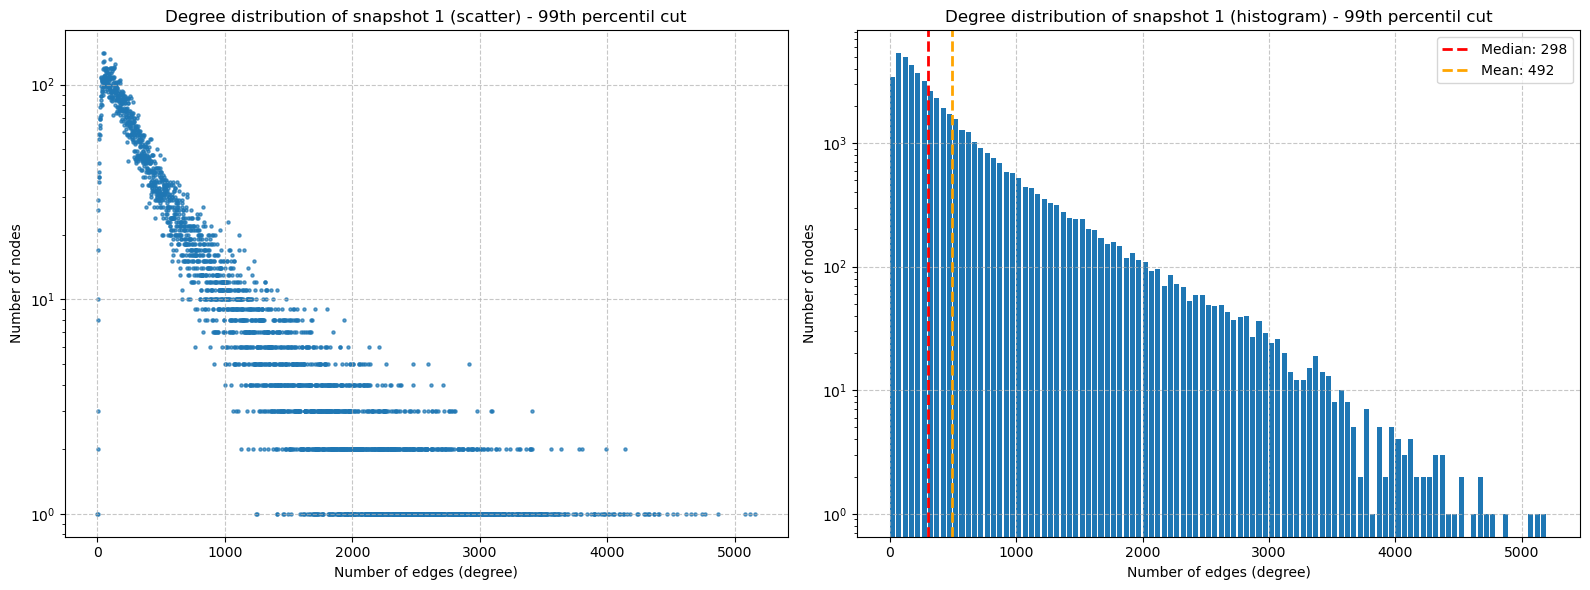


--- Processing: fasttext_snap2_filt.vec ---
Loading 47189 vectors of dimension 100...
Final shape: (47189, 100)
50%: 0.2672
75%: 0.3420
90%: 0.4122
95%: 0.4548
99%: 0.5355


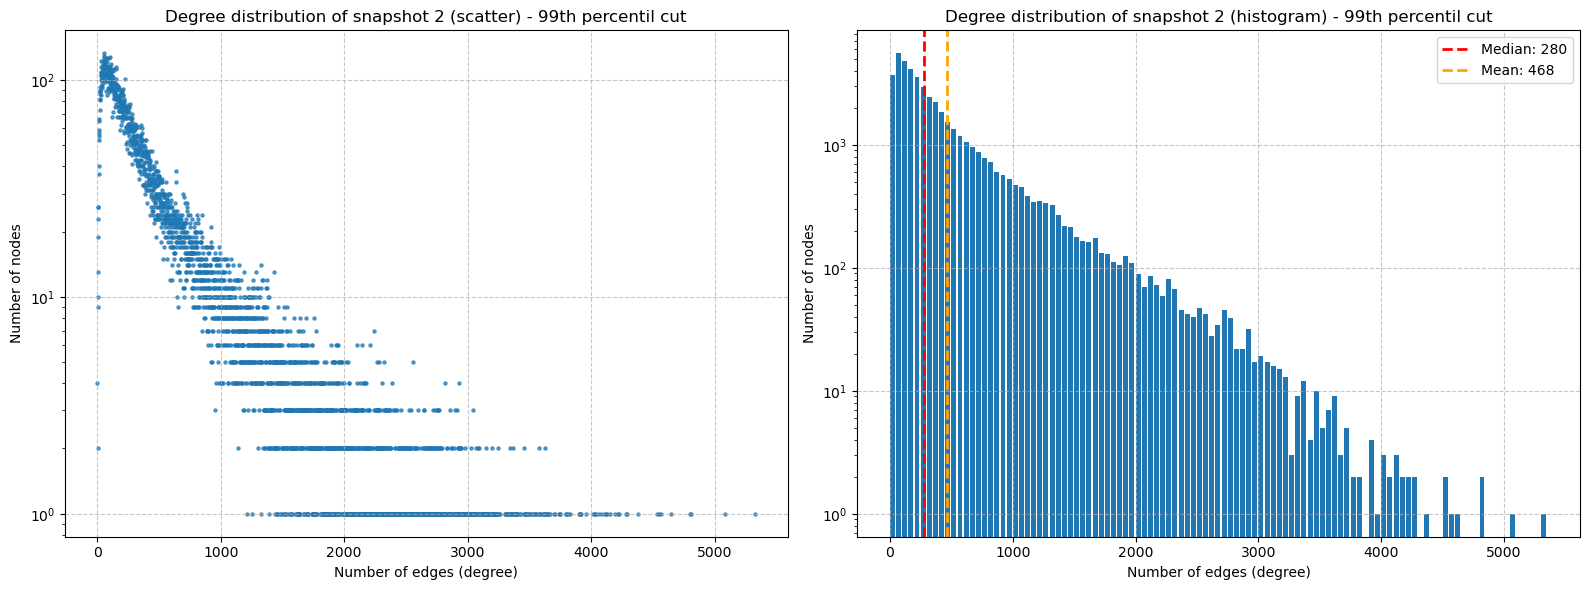


--- Processing: fasttext_snap3_filt.vec ---
Loading 64187 vectors of dimension 100...
Final shape: (64187, 100)
50%: 0.2642
75%: 0.3399
90%: 0.4110
95%: 0.4543
99%: 0.5367


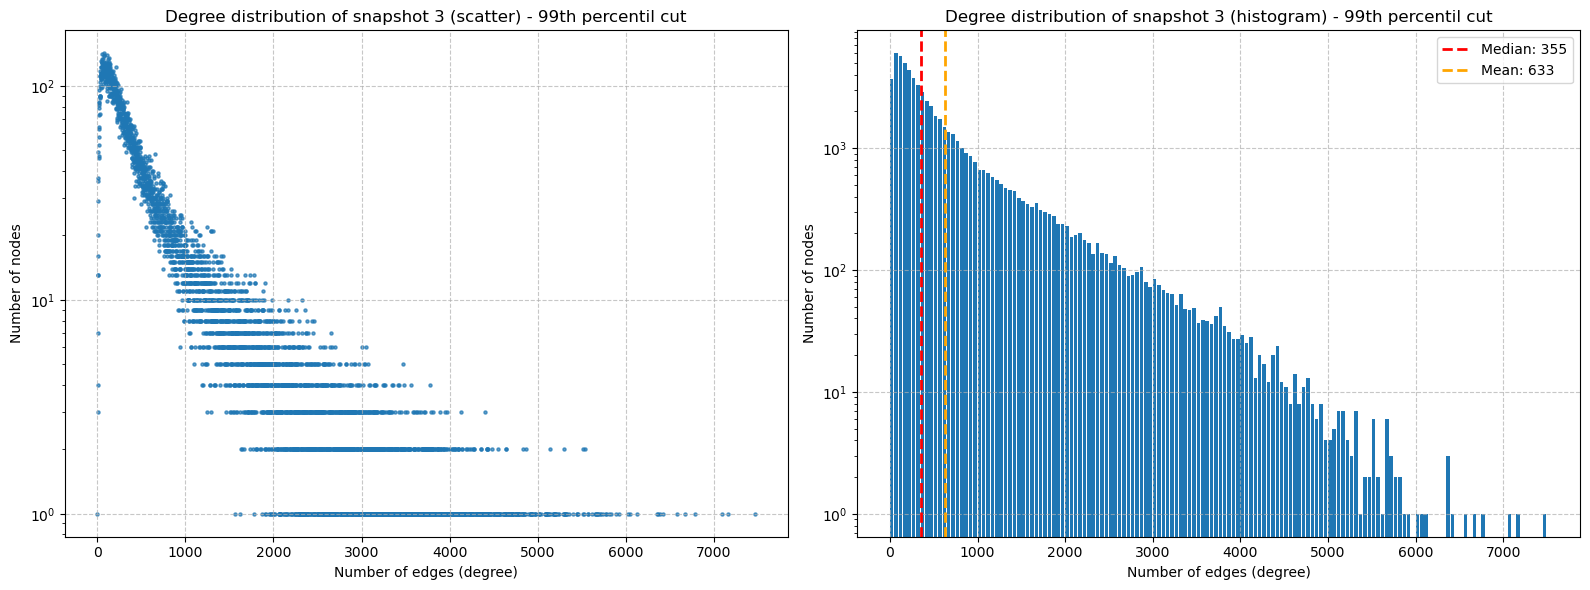


--- Processing: fasttext_snap4_filt.vec ---
Loading 64631 vectors of dimension 100...
Final shape: (64631, 100)
50%: 0.2633
75%: 0.3395
90%: 0.4109
95%: 0.4541
99%: 0.5357


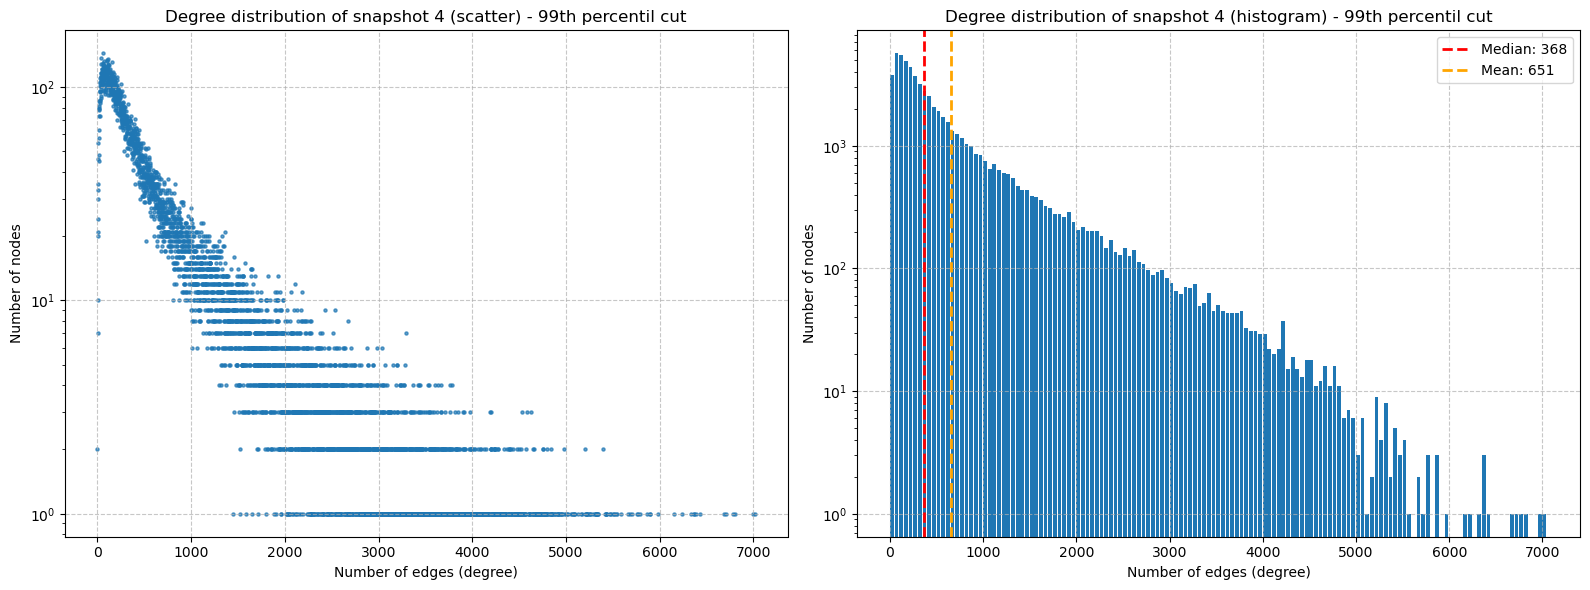


--- Processing: fasttext_snap5_filt.vec ---
Loading 75488 vectors of dimension 100...
Final shape: (75488, 100)
50%: 0.2727
75%: 0.3484
90%: 0.4186
95%: 0.4610
99%: 0.5406


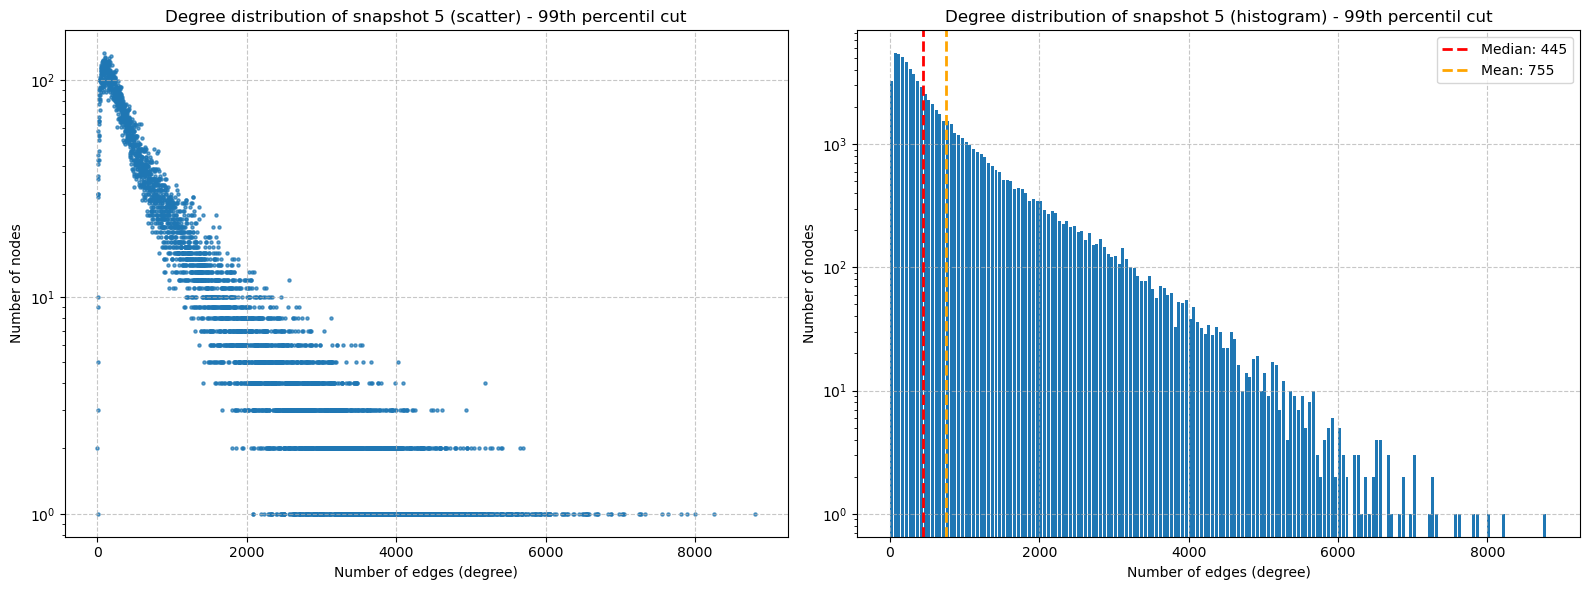


--- Processing: fasttext_snap6_filt.vec ---
Loading 82826 vectors of dimension 100...
Final shape: (82826, 100)
50%: 0.2726
75%: 0.3461
90%: 0.4141
95%: 0.4555
99%: 0.5337


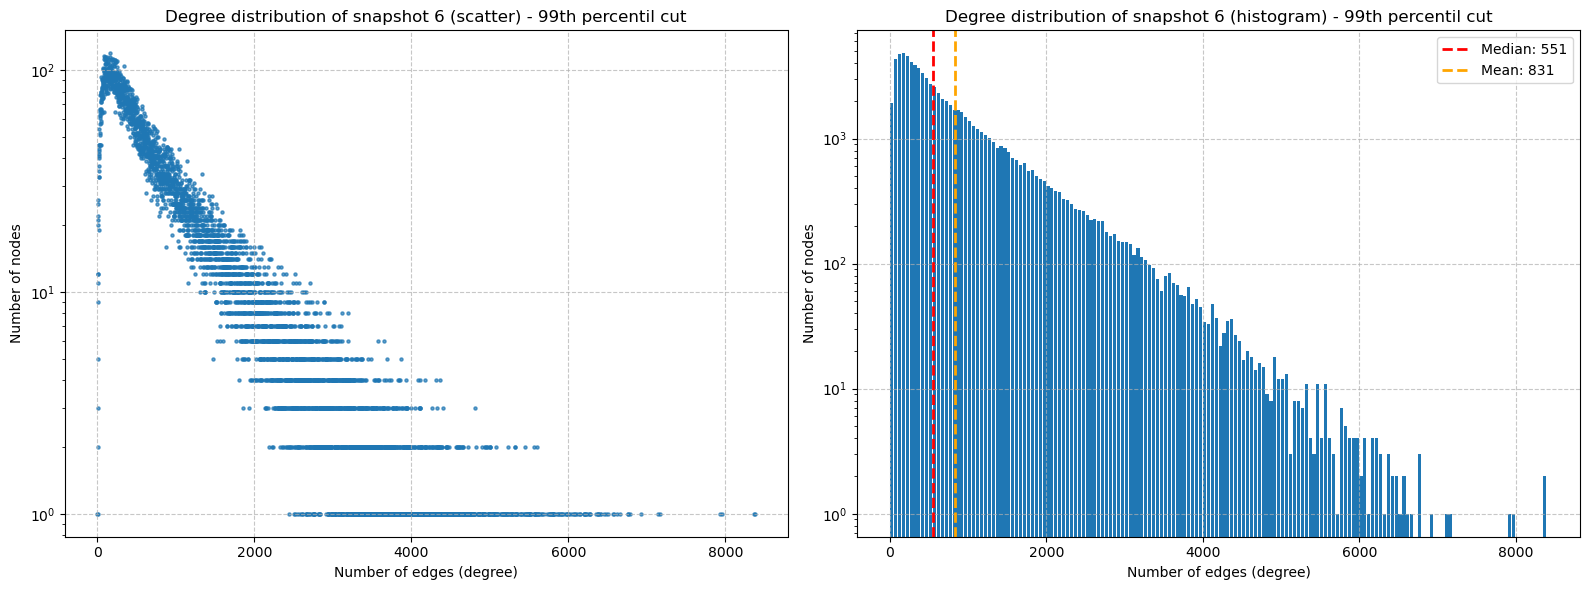


--- Processing: fasttext_snap7_filt.vec ---
Loading 64187 vectors of dimension 100...
Final shape: (64187, 100)
50%: 0.2766
75%: 0.3505
90%: 0.4187
95%: 0.4596
99%: 0.5363


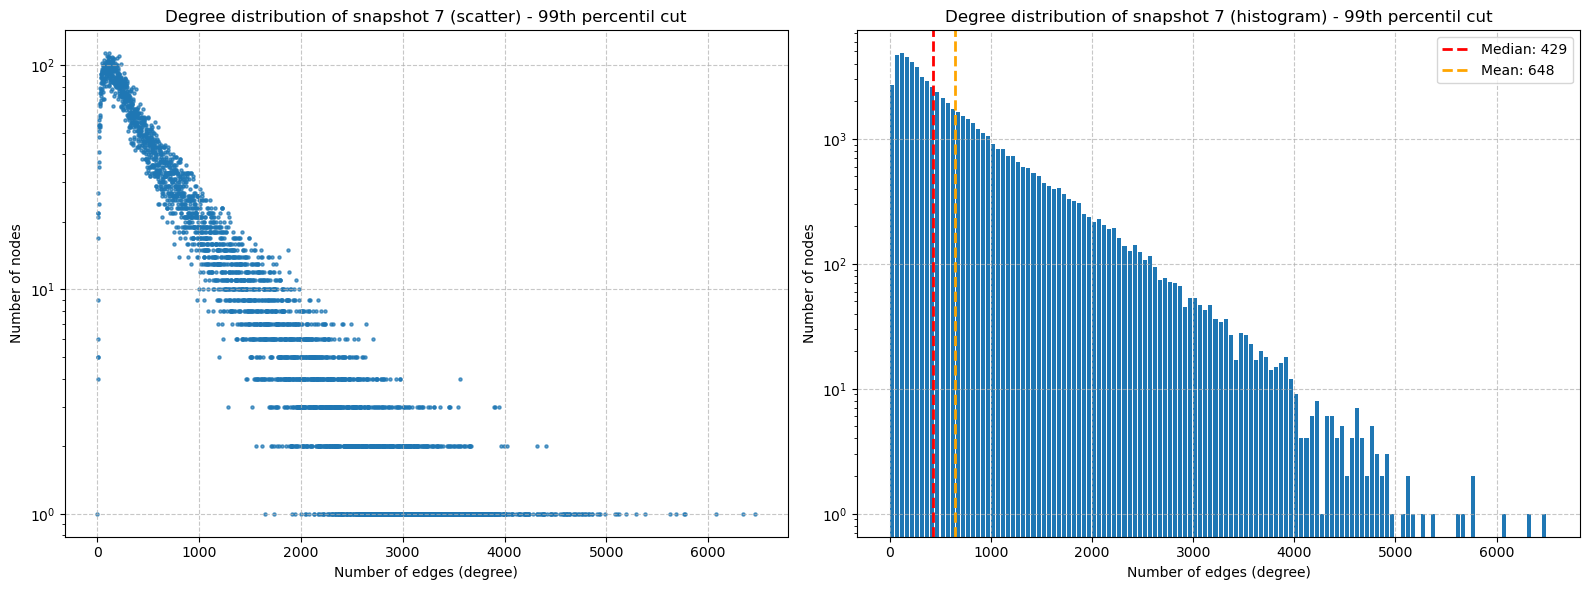


--- Processing: fasttext_snap8_filt.vec ---
Loading 58410 vectors of dimension 100...
Final shape: (58410, 100)
50%: 0.2621
75%: 0.3376
90%: 0.4082
95%: 0.4509
99%: 0.5310


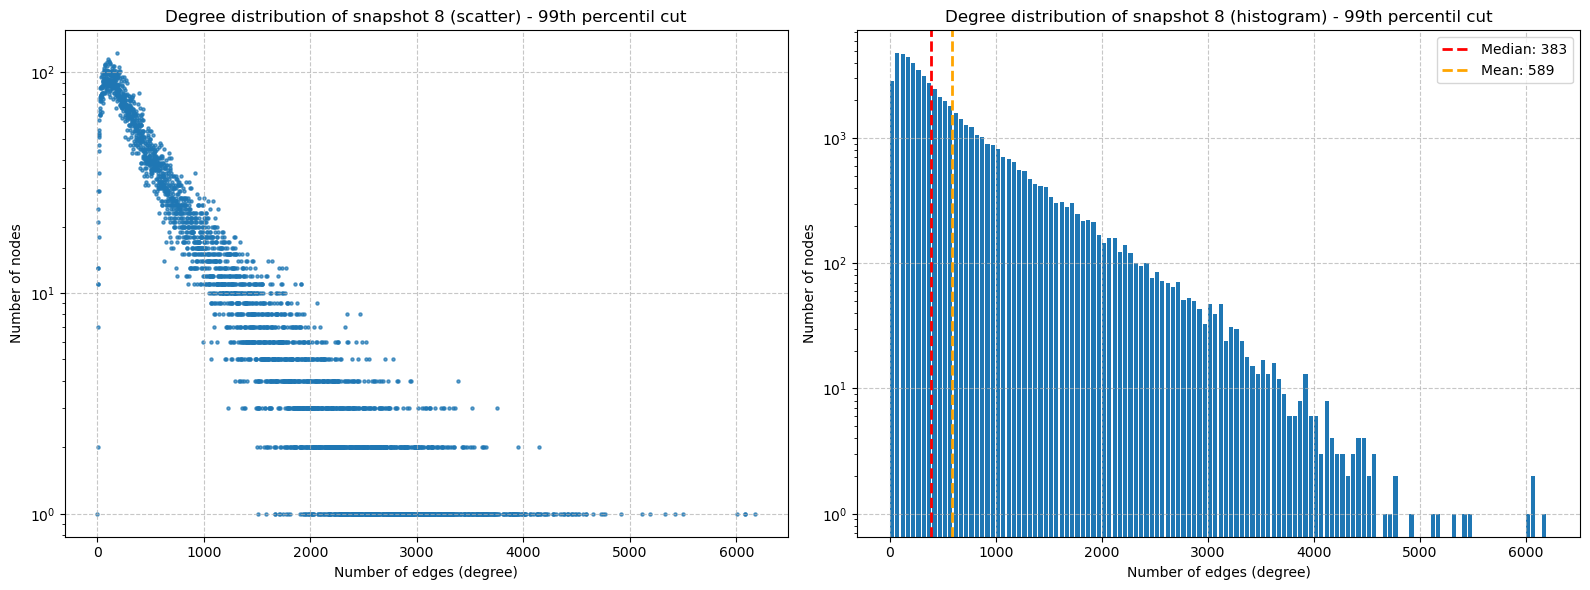


--- Processing: fasttext_snap9_filt.vec ---
Loading 52701 vectors of dimension 100...
Final shape: (52701, 100)
50%: 0.2601
75%: 0.3349
90%: 0.4048
95%: 0.4472
99%: 0.5266


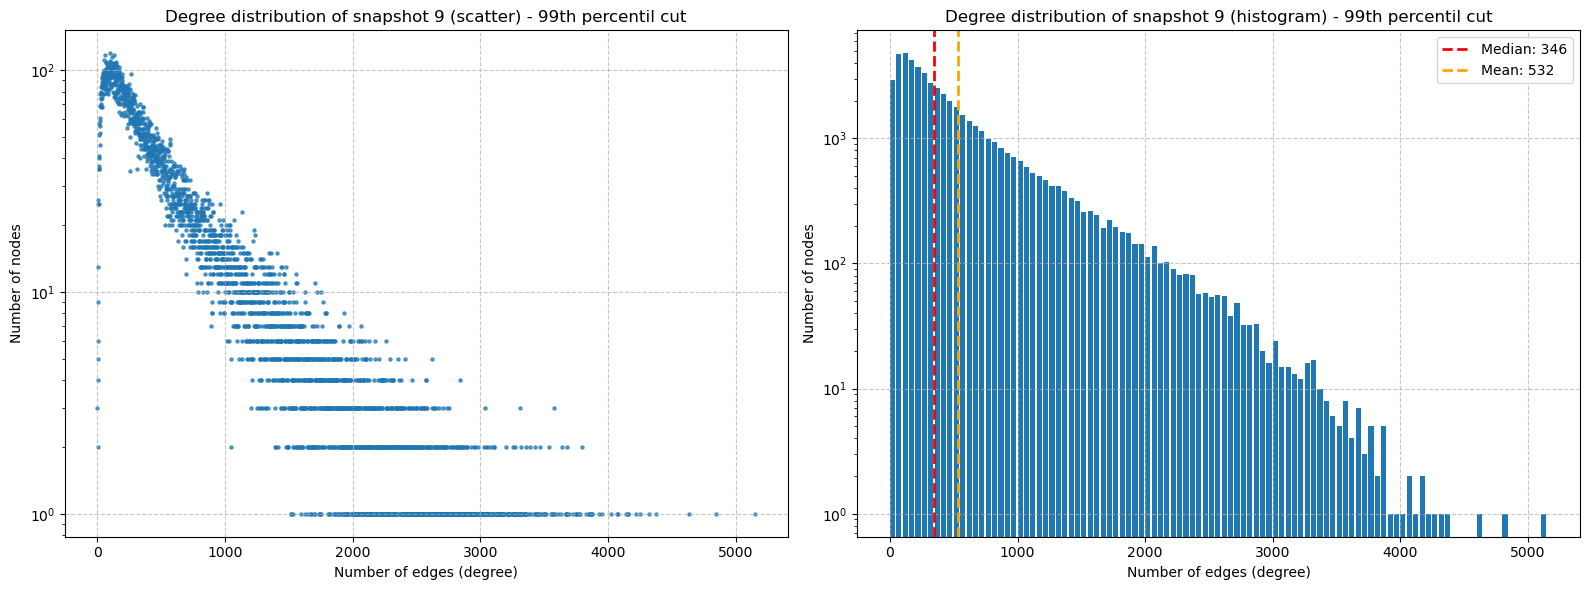


--- Processing: fasttext_snap10_filt.vec ---
Loading 48872 vectors of dimension 100...
Final shape: (48872, 100)
50%: 0.2713
75%: 0.3474
90%: 0.4183
95%: 0.4611
99%: 0.5406


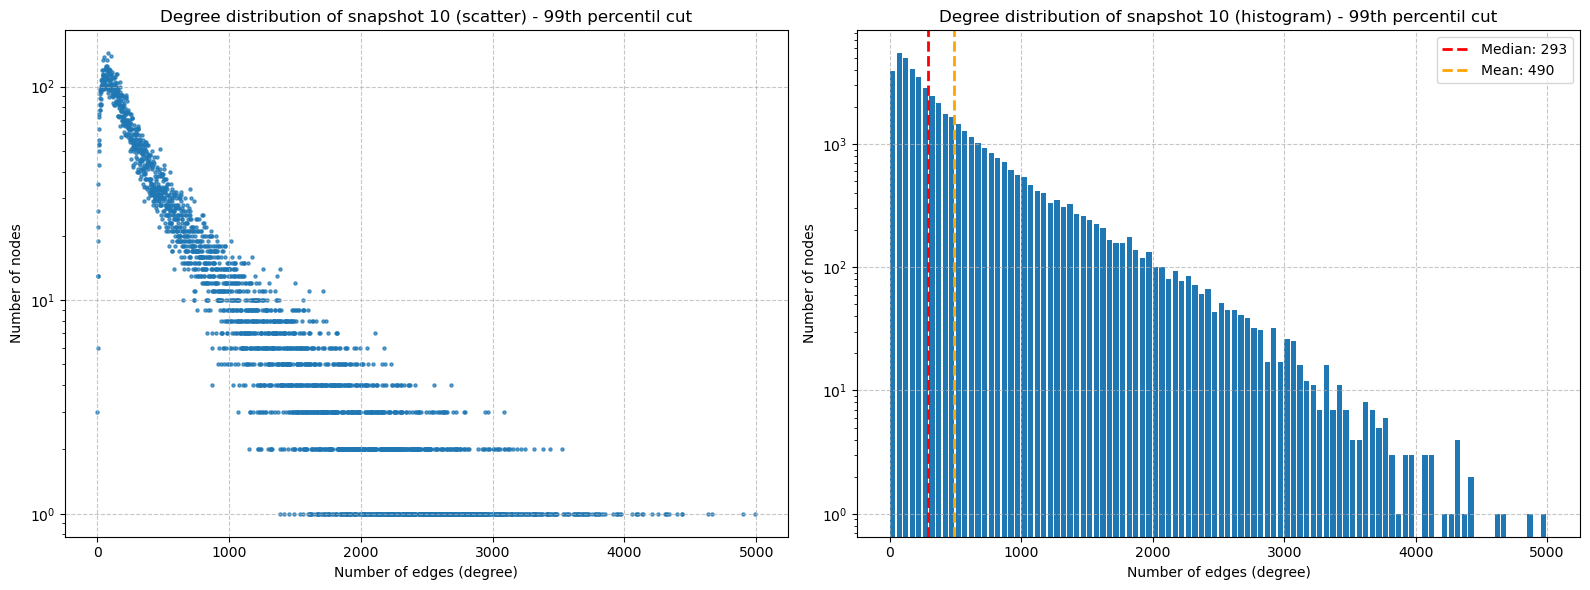

In [10]:
print_similarity_stats_sustainable(emb_dir)

In [7]:
# print_similarity_stats_sustainable(emb_dir, 95)

In [8]:
def save_nodes_edges(
    emb_dir,
    out_dir,
    perc=99,
    block_size=1024
):
    os.makedirs(out_dir, exist_ok=True)

    for snap in range(1, 11):
        fname = f"fasttext_snap{snap}_filt.vec"
        file_path = os.path.join(emb_dir, fname)

        print(f"\n--- Processing: {fname} ---")

        vectors = read_vec_file(file_path)
        vectors = vectors.astype("float32")
        vectors = normalize(vectors, axis=1)

        n = vectors.shape[0]

        # percentile threshold (Monte Carlo estimate)
        threshold = estimate_similarity_percentiles(vectors, [perc])[0]
        print(f"Similarity threshold @ p{perc}: {threshold:.4f}")

        out_path = os.path.join(out_dir, f"edges_snap{snap}_p{perc}.tsv")

        with open(out_path, "w") as f_out:
            f_out.write("i\tj\tsimilarity\n")

            for start in range(0, n, block_size):
                end = min(start + block_size, n)
                block = vectors[start:end]

                # cosine similarities
                sims = block @ vectors.T  # (block_size, n)

                # indices where similarity exceeds threshold
                ii, jj = np.where(sims > threshold)

                for bi, j in zip(ii, jj):
                    i = start + bi

                    # remove self-edges
                    if i >= j:
                        continue

                    sim = sims[bi, j]
                    f_out.write(f"{i}\t{j}\t{sim:.6f}\n")

        print(f"Saved edges to {out_path}")

In [9]:
out_dir = 'edges'

save_nodes_edges(emb_dir, out_dir)


--- Processing: fasttext_snap1_filt.vec ---
Loading 49460 vectors of dimension 100...
Final shape: (49460, 100)
Similarity threshold @ p99: 0.5364
Saved edges to edges/edges_snap1_p99.tsv

--- Processing: fasttext_snap2_filt.vec ---
Loading 47189 vectors of dimension 100...
Final shape: (47189, 100)
Similarity threshold @ p99: 0.5355
Saved edges to edges/edges_snap2_p99.tsv

--- Processing: fasttext_snap3_filt.vec ---
Loading 64187 vectors of dimension 100...
Final shape: (64187, 100)
Similarity threshold @ p99: 0.5367
Saved edges to edges/edges_snap3_p99.tsv

--- Processing: fasttext_snap4_filt.vec ---
Loading 64631 vectors of dimension 100...
Final shape: (64631, 100)
Similarity threshold @ p99: 0.5357
Saved edges to edges/edges_snap4_p99.tsv

--- Processing: fasttext_snap5_filt.vec ---
Loading 75488 vectors of dimension 100...
Final shape: (75488, 100)
Similarity threshold @ p99: 0.5406
Saved edges to edges/edges_snap5_p99.tsv

--- Processing: fasttext_snap6_filt.vec ---
Loading 82